In [1]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import math
import numpy as np

import pandas as pd

import os

import autoroot

from src.analysis import symmetric_kl
from notebooks.utils.plots import GOES_COLOR, IFS_COLOR, ICON_COLOR

/sw/spack-levante/mambaforge-23.1.0-1-Linux-x86_64-3boc6i/lib/python3.10/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [3]:
from notebooks.utils.patch_likelihoods import load_likelihood_dfs, load_all_dataset_likelihoods
import os
likelihood_dir_64x64 = os.environ.get('RESULTS_DIR_64x64')

datasets = [
    "goes_train", 
    "goes_test",
    "ifs_train",
    "ifs_test",
    "icon_train",
    "icon_test"
]

likelihood_dfs = load_likelihood_dfs(likelihood_dir_64x64, datasets, add_land_ocean=True)
all_dataset_likelihoods = load_all_dataset_likelihoods(likelihood_dir_64x64, datasets, add_land_ocean=True)

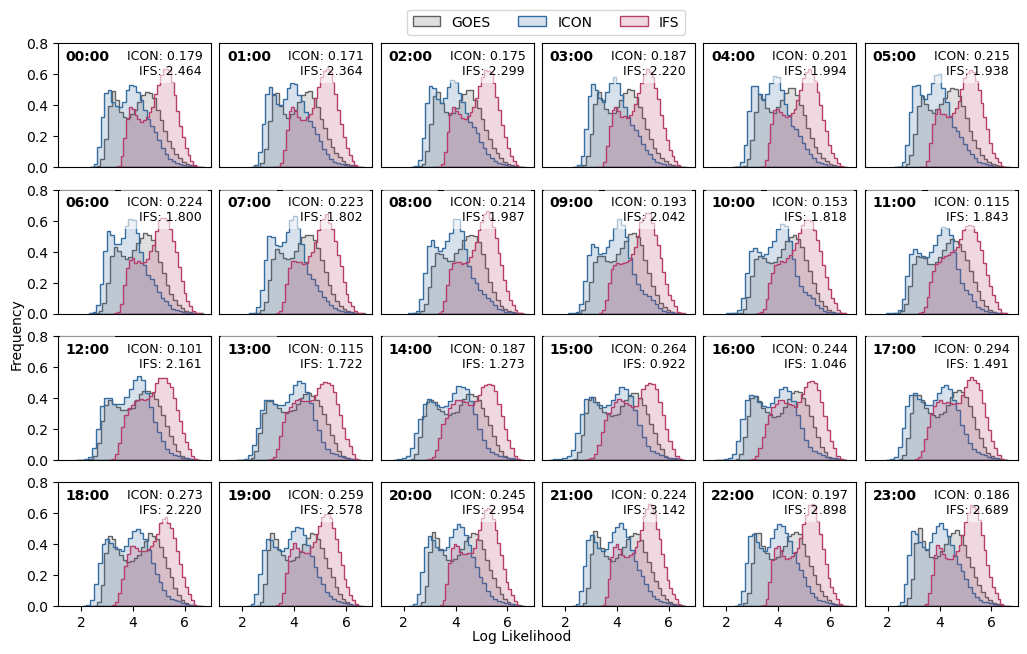

In [5]:
# make sure 'hour' is int and calculate local solar time
for df in all_dataset_likelihoods.values():
    df['hour'] = df['hour'].astype(int)
    # LST = GMT + longitude/15, wrap around 24 hours
    df['hour_LST'] = (df['hour'] + df['lon'] / 15) % 24
    # Optional: convert to integer hours for binning
    df['hour_LST'] = df['hour_LST'].astype(int)

plot_keys = ["goes", "icon", "ifs"]

fig, axes = plt.subplots(4, 6, figsize=(10, 6), sharex=True, sharey=True, constrained_layout=True)

# loop over local solar hours 0–23
for h, ax in enumerate(axes.flat):
    subsets = {}
    for key in plot_keys:
        df = all_dataset_likelihoods[key]
        subset = df[df['hour_LST'] == h]['bpd']
        subsets[key] = subset

        if "goes" in key:
            base_color = GOES_COLOR
        elif "ifs" in key:
            base_color = IFS_COLOR
        elif "icon" in key:
            base_color = ICON_COLOR

        n, bins, patches = ax.hist(
            subset,
            bins=30,
            label=key.upper() if h == 0 else None,
            color=base_color + (0.2,),
            edgecolor=mcolors.to_hex(base_color),
            histtype='stepfilled',
            density=True,
        )

    # compute and annotate KL divergences
    if len(subsets["goes"]) > 0 and len(subsets["icon"]) > 0:
        skl_goes_icon = symmetric_kl(subsets["goes"], subsets["icon"])
    else:
        skl_goes_icon = np.nan

    if len(subsets["goes"]) > 0 and len(subsets["ifs"]) > 0:
        skl_goes_ifs = symmetric_kl(subsets["goes"], subsets["ifs"])
    else:
        skl_goes_ifs = np.nan

    # add text box with results
    ax.text(
        0.45, 0.95,
        f"ICON: {skl_goes_icon:.3f}\n   IFS: {skl_goes_ifs:.3f}",
        color="black",
        transform=ax.transAxes,
        fontsize=9,
        verticalalignment="top",
        bbox=dict(facecolor="white", alpha=0.6, edgecolor="none")
    )

    ax.text(
        0.05, 0.95,
        f"{h:02d}:00",
        color="black",
        transform=ax.transAxes,
        fontsize=10,
        verticalalignment="top",
        bbox=dict(facecolor="white", alpha=0.6, edgecolor="none"),
        weight='bold'
    )

    if h % 6 != 0:
        # set ticklength to 0 for y-axis if not first column
        ax.tick_params(axis='y', length=0)

    if h < 18:
        # set ticklength to 0 for x-axis if not last row
        ax.tick_params(axis='x', length=0)
    ax.set_ylim(0, 0.8)


fig.text(0.5, -0.012, "Log Likelihood", ha="center", fontsize=10)
fig.text(-0.012, 0.5, "Frequency", va="center", rotation="vertical", fontsize=10)

# add legend outside grid
handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    bbox_to_anchor=(0.67, 1.052),
    ncol=len(labels),
)

plt.show()